# Load silver to gold

## Imports

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind, f_oneway, chi2_contingency, spearmanr, pearsonr
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Main

### Cargar los datos de silver

In [2]:
silver_path = os.path.join(
    os.curdir, "Data_Lake", "Silver"
)

In [3]:
silver_file_name = "menstrual_cycle_silver.parquet"

In [4]:
silver_file_path = os.path.join(
    silver_path, silver_file_name
)

In [5]:
silver_menstrual_cycle_df = pd.read_parquet(silver_file_path)

In [6]:
silver_menstrual_cycle_df.head()

,User ID,Age,Stress Level,Exercise Frequency,Sleep Hours,Diet,Cycle Start Date,Cycle Length,Period Length,Next Cycle Start Date,Symptoms,BMI,_BronzeTimestamp
index,,,,,,,,,,,,,
0,1.0,18.0,2.0,Moderate,54.0,Low Carb,2024-11-13 20:52:00,26,7.0,2024-12-09 20:52:00,Headache,29.28,2025-11-06 19:16:40.445350
1,1.0,18.0,2.0,Moderate,54.0,Low Carb,2024-12-09 20:52:00,32,5.0,2025-01-10 20:52:00,Fatigue,29.28,2025-11-06 19:16:40.445350
2,1.0,18.0,2.0,Moderate,54.0,Low Carb,2025-01-10 20:52:00,41,7.0,2025-02-20 20:52:00,Fatigue,29.28,2025-11-06 19:16:40.445350
3,1.0,18.0,2.0,Moderate,54.0,Low Carb,2025-02-20 20:52:00,27,3.0,2025-03-19 20:52:00,Fatigue,29.28,2025-11-06 19:16:40.445350
4,1.0,18.0,2.0,Moderate,54.0,Low Carb,2025-03-19 20:52:00,42,5.0,2025-04-30 20:52:00,Cramps,29.28,2025-11-06 19:16:40.445350


### Agrupaciones y medidas

In [7]:
# Agrupacion por frecuencia de ejercicio fisico
agrupacion_exercise_frequency = (
    silver_menstrual_cycle_df.groupby("Exercise Frequency")
    .agg({
        "Period Length": "mean",
        "Cycle Length": "mean"
        
    })
)
agrupacion_exercise_frequency = agrupacion_exercise_frequency.reset_index() #creamos indice

In [8]:
agrupacion_exercise_frequency.head()
# Hacer mas o menos ejercicio parece no influir de manera notable en la duracion del periodo o sangrado. 
# Si que parece que cuando más ejericio haces, más largo es el ciclo y más sangrado en el periodo.

,Exercise Frequency,Period Length,Cycle Length
0,High,5.113433,37.552239
1,Low,4.925907,36.790323
2,Moderate,4.996756,37.412409


In [9]:
# Agrupación por nivel de estrés
agrupacion_stress_level = (
    silver_menstrual_cycle_df.groupby("Stress Level")
    .agg({
        "Period Length": "mean",
        "Cycle Length": "mean",
        "Sleep Hours" : "mean"
    })
)
agrupacion_stress_level = agrupacion_stress_level.reset_index() #creamos indice

In [10]:
agrupacion_stress_level.head() # Evidentemente a mas estrés, menos horas dormidas

,Stress Level,Period Length,Cycle Length,Sleep Hours
0,1.0,5.017381,36.810056,72.206704
1,2.0,4.879747,37.924051,70.702532
2,3.0,5.027972,37.447552,71.209790
3,4.0,5.110923,37.198198,67.842342
4,5.0,5.038710,37.167742,66.877419


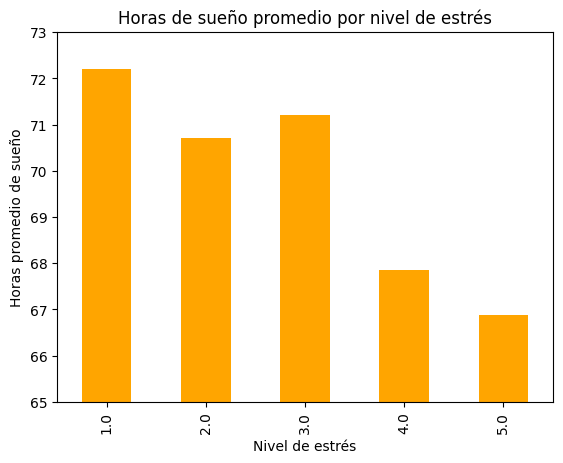

In [11]:
agrupacion_stress_level.plot(x='Stress Level',y='Sleep Hours',kind='bar',legend=0, color='orange')
plt.ylim(65, 73)
plt.title('Horas de sueño promedio por nivel de estrés')
plt.xlabel('Nivel de estrés')
plt.ylabel('Horas promedio de sueño')
plt.show()

In [12]:
# agrupacion por Fechas de incio de ciclo
df_fecha = (
    silver_menstrual_cycle_df.groupby(pd.Grouper(key='Cycle Start Date', freq='M'))['Cycle Length']
      .mean()
      .reset_index()
)

C:\Users\cadav\AppData\Local\Temp\ipykernel_36096\452823145.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  silver_menstrual_cycle_df.groupby(pd.Grouper(key='Cycle Start Date', freq='M'))['Cycle Length']


In [13]:
def obtener_estacion(mes):
    """
    Devuelve la estación del año correspondiente a un número de mes.
        - Invierno: diciembre (12), enero (1), febrero (2)
        - Primavera: marzo (3), abril (4), mayo (5)
        - Verano: junio (6), julio (7), agosto (8)
        - Otoño: septiembre (9), octubre (10), noviembre (11)
    Args:
        mes (int): Número del mes (1 = enero, 12 = diciembre).

    Returns:
        str: Nombre de la estación del año ('Invierno', 'Primavera',
             'Verano' u 'Otoño').
    """
    if mes in [12,1,2]: return 'Invierno'
    elif mes in [3,4,5]: return 'Primavera'
    elif mes in [6,7,8]: return 'Verano'
    else: return 'Otoño'

silver_menstrual_cycle_df['Estación'] = silver_menstrual_cycle_df['Cycle Start Date'].dt.month.map(obtener_estacion)

# Agrupacion por estacion y sintoma
symptoms_by_season = silver_menstrual_cycle_df.groupby(['Estación', 'Symptoms']).size().reset_index(name='Frecuencia')

In [14]:
# Agrupación por usuario
silver_menstrual_cycle_por_user_df = silver_menstrual_cycle_df

resumen_por_user = (
    silver_menstrual_cycle_por_user_df .groupby("User ID")
    .agg({
        "Cycle Length": ["mean", "std"],
        "Period Length": "mean",
        "Stress Level": "mean",
        "Sleep Hours": "mean",
        "BMI": "mean",
        "Age": "mean",
        "Diet": lambda x: x.mode()[0] if not x.mode().empty else None,
        "Exercise Frequency": lambda x: x.mode()[0] if not x.mode().empty else None,
        "Symptoms": lambda x: x.mode()[0] if not x.mode().empty else None,
        "Cycle Start Date": "count"  # número de ciclos
    })
)

# Renombrar columnas
resumen_por_user.columns = [
    "Avg Cycle Length",
    "Cycle Length Std",
    "Avg Period Length",
    "Avg Stress",
    "Avg Sleep",
    "Avg BMI",
    "Avg Age",
    "Most Common Diet",
    "Most Common Exercise",
    "Most Common Symptom",
    "Cycle Count"
]

resumen_por_user = resumen_por_user.reset_index() #creamos indice

In [15]:
resumen_por_user.head()

,User ID,Avg Cycle Length,Cycle Length Std,Avg Period Length,Avg Stress,Avg Sleep,Avg BMI,Avg Age,Most Common Diet,Most Common Exercise,Most Common Symptom,Cycle Count
0,1.0,36.909091,8.055489,4.909091,2.0,54.0,29.28,18.0,Low Carb,Moderate,Fatigue,11
1,2.0,34.444444,6.023104,5.625000,4.0,54.0,29.57,34.0,Low Carb,Low,Bloating,9
2,3.0,40.200000,8.689713,4.111111,1.0,86.0,29.44,22.0,Vegetarian,Moderate,Cramps,10
3,4.0,40.200000,7.130529,4.800000,2.0,83.0,25.68,25.0,Vegetarian,Moderate,Mood Swings,10
4,5.0,38.333333,6.227992,5.333333,1.0,63.0,25.27,25.0,Low Carb,High,Bloating,12


### Búsqueda de correlaciones

#### Variables Numérica-Numérica:

In [16]:
# Sleep Hours vs Cycle_length (más horas dormidas, ciclos más estables)
silver_menstrual_cycle_df.corr(numeric_only=True) # ningun valor cerca de 1

,User ID,Age,Stress Level,Sleep Hours,Cycle Length,Period Length,BMI
User ID,1.000000,0.109512,0.206640,0.240381,0.023169,0.033680,-0.179659
Age,0.109512,1.000000,0.084107,0.057399,-0.014281,0.032707,-0.080268
Stress Level,0.206640,0.084107,1.000000,-0.156851,0.001485,0.029263,-0.021113
Sleep Hours,0.240381,0.057399,-0.156851,1.000000,0.044759,-0.038719,-0.001322
Cycle Length,0.023169,-0.014281,0.001485,0.044759,1.000000,-0.000710,0.023446
Period Length,0.033680,0.032707,0.029263,-0.038719,-0.000710,1.000000,-0.034792
BMI,-0.179659,-0.080268,-0.021113,-0.001322,0.023446,-0.034792,1.000000


#### Variables Numérica-Categórica:

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1  group2  meandiff p-adj   lower  upper  reject
-----------------------------------------------------
  High      Low  -0.1875 0.2381 -0.4594 0.0844  False
  High Moderate  -0.1167 0.5543 -0.3811 0.1477  False
   Low Moderate   0.0708 0.8284 -0.2137 0.3554  False
-----------------------------------------------------


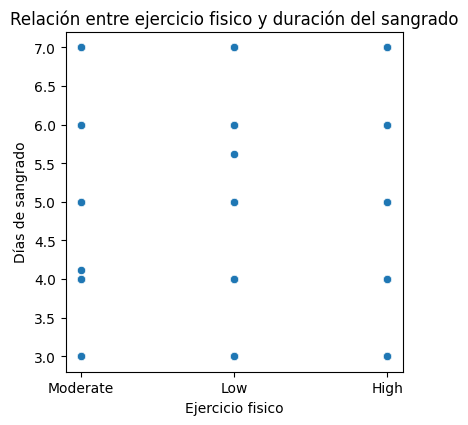

In [17]:
# Frecuencia de ejercicio fisico y duracion de sangrado
fig = plt.figure(figsize=(20, 15))
ax4 = plt.subplot2grid((3,4),(0,0))
sns.scatterplot(data=silver_menstrual_cycle_por_user_df, x='Exercise Frequency', y='Period Length')
ax4.set_title('Relación entre ejercicio fisico y duración del sangrado')
ax4.set_xlabel('Ejercicio fisico')
ax4.set_ylabel('Días de sangrado')

tukey = pairwise_tukeyhsd(silver_menstrual_cycle_por_user_df['Period Length'], silver_menstrual_cycle_por_user_df['Exercise Frequency'])
print(tukey) # todas False: No hay relación

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1  group2  meandiff p-adj   lower  upper  reject
-----------------------------------------------------
  High      Low  -0.1875 0.2381 -0.4594 0.0844  False
  High Moderate  -0.1167 0.5543 -0.3811 0.1477  False
   Low Moderate   0.0708 0.8284 -0.2137 0.3554  False
-----------------------------------------------------


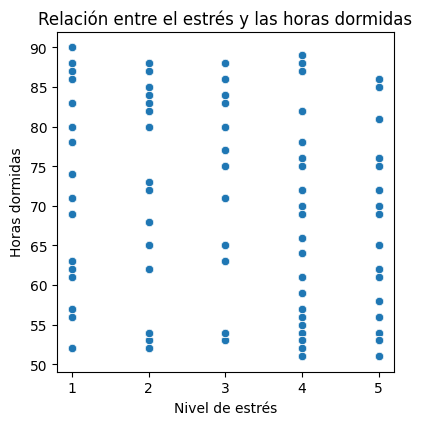

In [18]:
# Estrés y horas dormidas
fig = plt.figure(figsize=(20, 15))
ax4 = plt.subplot2grid((3,4),(0,0))
sns.scatterplot(data=silver_menstrual_cycle_df, x='Stress Level', y='Sleep Hours')
ax4.set_title('Relación entre el estrés y las horas dormidas')
ax4.set_xlabel('Nivel de estrés')
ax4.set_ylabel('Horas dormidas')

tukey = pairwise_tukeyhsd(silver_menstrual_cycle_df['Period Length'], silver_menstrual_cycle_df['Exercise Frequency'])
print(tukey) # todas False: No hay relación

### Dashboard de gráficos

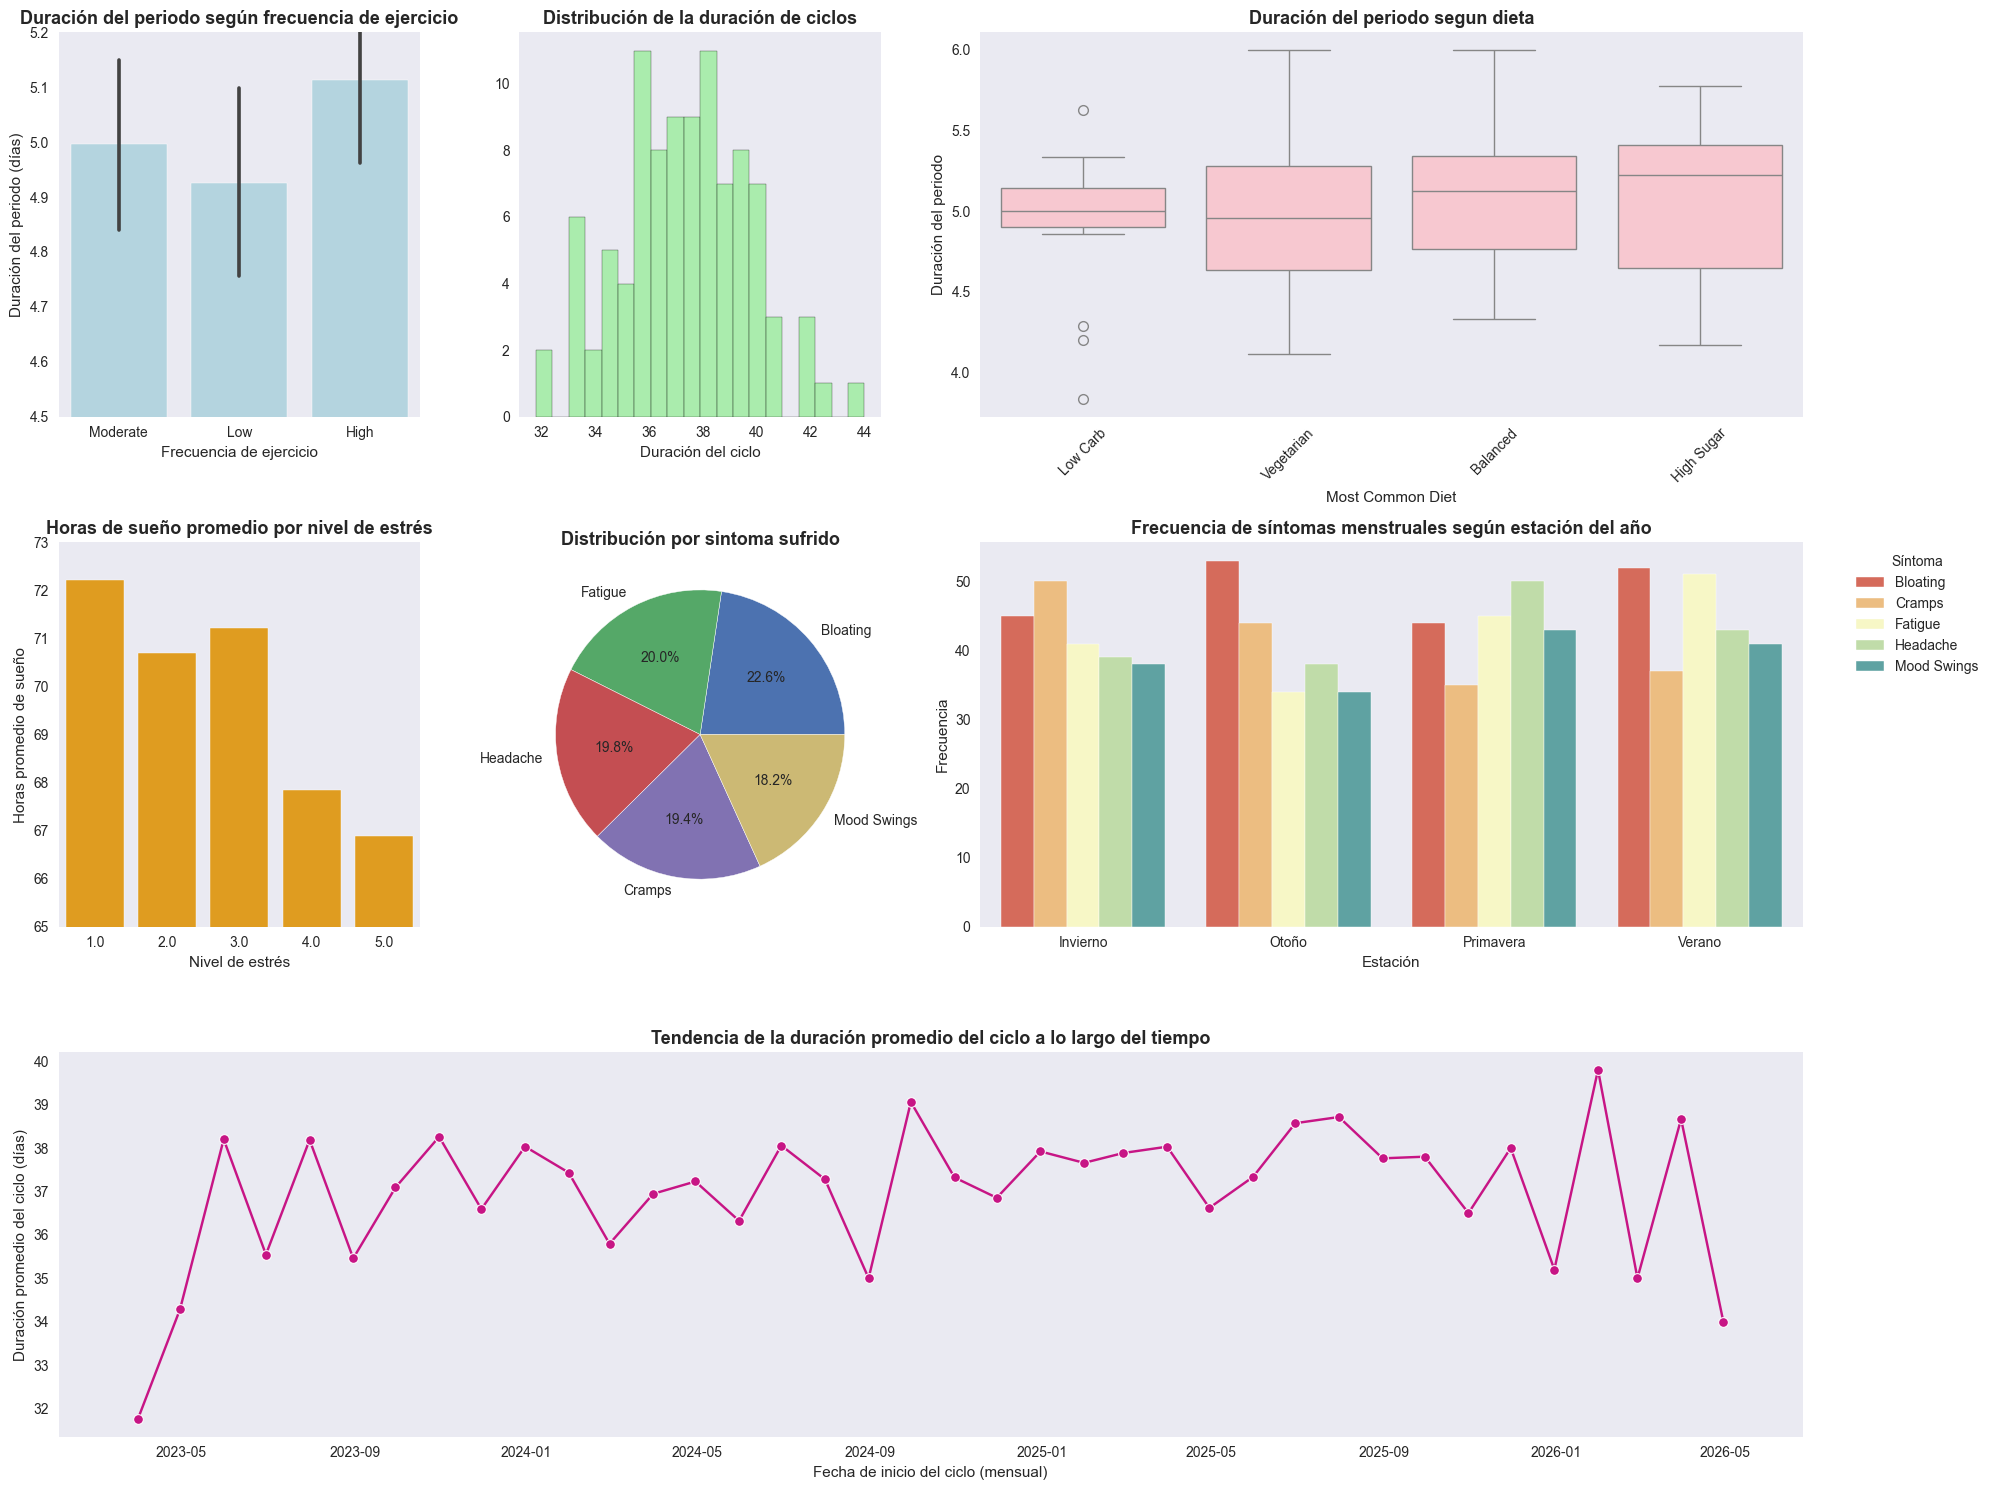

📊 RESUMEN ESTADÍSTICO:
Mujeres totales: 97
Edad promedio: 31.3 años
Duracion promedio del ciclo menstrual: 37.36 días
Duracion promedio del sangrado: 5.01 días
Síntoma más frecuente: Bloating


In [19]:
# Configurar el estilo
plt.style.use('seaborn-v0_8')
sns.set_style("dark")
sns.color_palette("rocket")

# Crear figura principal
fig = plt.figure(figsize=(20, 15))

# 1. 
ax1 = plt.subplot2grid((3, 4), (0, 0))
sns.barplot(data=silver_menstrual_cycle_df, x='Exercise Frequency', y='Period Length', color='lightblue')
plt.ylim(4.5, 5.2)
ax1.set_title('Duración del periodo según frecuencia de ejercicio',  fontsize=13, weight='bold')
ax1.set_xlabel('Frecuencia de ejercicio')
ax1.set_ylabel('Duración del periodo (días)')

# 2. Distribución duración ciclos menstruales
ax2 = plt.subplot2grid((3, 4), (0, 1))
ax2.hist(resumen_por_user['Avg Cycle Length'], bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
ax2.set_title('Distribución de la duración de ciclos',  fontsize=13, weight='bold')
ax2.set_xlabel('Duración del ciclo')

# 3. Efecto de la dieta
ax3 = plt.subplot2grid((3, 4), (0, 2), colspan=2)
sns.boxplot(data=resumen_por_user, x='Most Common Diet', y='Avg Period Length', ax=ax3, color='pink')
ax3.set_title('Duración del periodo segun dieta',  fontsize=13, weight='bold')
ax3.set_ylabel('Duración del periodo')
ax3.tick_params(axis='x', rotation=45)

# 4. Recuento de sintomas
ax4 = plt.subplot2grid((3, 4), (1, 0))
sns.barplot(
    data=agrupacion_stress_level,
    x='Stress Level',
    y='Sleep Hours',
    color='orange'
)
plt.ylim(65, 73)
ax4.set_title('Horas de sueño promedio por nivel de estrés',  fontsize=13, weight='bold')
ax4.set_xlabel('Nivel de estrés')
ax4.set_ylabel('Horas promedio de sueño')

# 5. Recuento de sintomas
ax5 = plt.subplot2grid((3, 4), (1, 1))
recuento_sintomas = silver_menstrual_cycle_df['Symptoms'].value_counts()
ax5.pie(recuento_sintomas.values, labels=recuento_sintomas.index, autopct='%1.1f%%')
ax5.set_title('Distribución por sintoma sufrido', fontsize=13, weight='bold')

# 6
ax6 = plt.subplot2grid((3, 4), (1, 2), colspan=2)
sns.barplot(
    data=symptoms_by_season,
    x='Estación',
    y='Frecuencia',
    hue='Symptoms',
    palette='Spectral'
)
ax6.set_title('Frecuencia de síntomas menstruales según estación del año', fontsize=13, weight='bold')
ax6.set_xlabel('Estación')
ax6.set_ylabel('Frecuencia')
ax6.legend(title='Síntoma', bbox_to_anchor=(1.05, 1), loc='upper left')

# 7
ax7 = plt.subplot2grid((3, 4), (2, 0), colspan=4)
sns.lineplot(
    data=df_fecha,
    x='Cycle Start Date',
    y='Cycle Length',
    marker='o',
    color='mediumvioletred'
)
ax7.set_title('Tendencia de la duración promedio del ciclo a lo largo del tiempo', fontsize=13, weight='bold')
ax7.set_xlabel('Fecha de inicio del ciclo (mensual)')
ax7.set_ylabel('Duración promedio del ciclo (días)')

plt.tight_layout()
plt.show()

print("📊 RESUMEN ESTADÍSTICO:")
print(f"Mujeres totales: {len(resumen_por_user)}")
print(f"Edad promedio: {resumen_por_user['Avg Age'].mean():.1f} años")
print(f"Duracion promedio del ciclo menstrual: {resumen_por_user['Avg Cycle Length'].mean():.2f} días")
print(f"Duracion promedio del sangrado: {resumen_por_user['Avg Period Length'].mean():.2f} días")
print(f"Síntoma más frecuente: {silver_menstrual_cycle_df['Symptoms'].mode()[0]}")